In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, math, pickle, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':12,'figure.dpi':150,'font.family':'sans-serif','axes.grid':True,'grid.alpha':0.3})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [3]:
DATA_DIR = '/content/drive/MyDrive/LSTGAN_Data/results'
CKPT_PATH  = os.path.join(DATA_DIR, 'best_lstgan.pt')
GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_5min.pkl')
VAL_FILE   = os.path.join(DATA_DIR, 'val_5min.pkl')
TEST_FILE  = os.path.join(DATA_DIR, 'test_5min.pkl')

for name, path in [('Checkpoint',CKPT_PATH),('Graph',GRAPH_FILE),('Train',TRAIN_FILE),('Val',VAL_FILE),('Test',TEST_FILE)]:
    print(f'  {name:12s}: {"✓" if os.path.exists(path) else "✗ MISSING"} {path}')

NUM_SENSORS=325; STEPS_PER_HOUR=12; STEPS_PER_DAY=288
WEEKLY_WINDOW=2016; DAILY_WINDOW=288; HOURLY_WINDOW=12
FORECAST_HORIZON=12; EVAL_HORIZONS=[3,6,12]
WEEKLY_IN_CHANNELS=3; WEEKLY_OUT_CHANNELS=16
DAILY_IN_CHANNELS=3; DAILY_OUT_CHANNELS=8
HOURLY_IN_CHANNELS=1
WEEKLY_STRIDE_1=14; WEEKLY_STRIDE_2=12
DAILY_STRIDE_1=4; DAILY_STRIDE_2=6
SPATIAL_EMBED_DIM=16
GLOBAL_SPATIAL_CHANNELS=16; GLOBAL_ATTN_HEADS=4; GLOBAL_ATTN_LAYERS=1
LOCAL_SPATIAL_CHANNELS=8; CHEBYSHEV_K=5; GCN_LAYERS=1
D_MODEL=WEEKLY_OUT_CHANNELS+DAILY_OUT_CHANNELS+GLOBAL_SPATIAL_CHANNELS+LOCAL_SPATIAL_CHANNELS
TIME_ONEHOT_DIM=7+STEPS_PER_DAY
DECODER_HEADS=6; DECODER_HEAD_DIM=8; DECODER_LAYERS=1
BATCH_SIZE=8
print(f'D_MODEL={D_MODEL}, HORIZON={FORECAST_HORIZON}')

  Checkpoint  : ✓ /content/drive/MyDrive/LSTGAN_Data/results/best_lstgan.pt
  Graph       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/adj_mx_bay.pkl
  Train       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/train_5min.pkl
  Val         : ✓ /content/drive/MyDrive/LSTGAN_Data/results/val_5min.pkl
  Test        : ✓ /content/drive/MyDrive/LSTGAN_Data/results/test_5min.pkl
D_MODEL=48, HORIZON=12


In [4]:
class TrafficDataset(Dataset):
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode=mode; self.num_sensors=data_df.shape[1]
        self.mean=data_df.values.mean() if mean is None else mean
        self.std=data_df.values.std() if std is None else std
        self.speed=((data_df.values-self.mean)/(self.std+1e-8)).astype(np.float32)
        if hasattr(data_df.index,'weekday'):
            self.day_of_week=data_df.index.weekday.values
            self.time_of_day=(data_df.index.hour*12+data_df.index.minute//5).values
        else:
            T=len(data_df); self.day_of_week=np.arange(T)%7; self.time_of_day=np.arange(T)%STEPS_PER_DAY
        self.total_steps=len(self.speed); self.start_offset=WEEKLY_WINDOW
        self.valid_len=self.total_steps-self.start_offset-FORECAST_HORIZON+1
        assert self.valid_len>0
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')
    def __len__(self): return self.valid_len
    def _time_feats(self,idx,length):
        s=idx-length
        dow=self.day_of_week[s:idx].astype(np.float32)/6.0
        tod=self.time_of_day[s:idx].astype(np.float32)/287.0
        return np.stack([dow,tod],axis=-1)
    def __getitem__(self,idx):
        t=self.start_offset+idx; N=self.num_sensors
        sp_w=self.speed[t-WEEKLY_WINDOW:t]; tf_w=self._time_feats(t,WEEKLY_WINDOW)
        X_w=np.stack([sp_w,np.tile(tf_w[:,0:1],(1,N)),np.tile(tf_w[:,1:2],(1,N))],axis=-1)
        sp_d=self.speed[t-DAILY_WINDOW:t]; tf_d=self._time_feats(t,DAILY_WINDOW)
        X_d=np.stack([sp_d,np.tile(tf_d[:,0:1],(1,N)),np.tile(tf_d[:,1:2],(1,N))],axis=-1)
        X_h=self.speed[t-HOURLY_WINDOW:t][:,:,np.newaxis]
        t_info=np.array([self.day_of_week[t],self.time_of_day[t]],dtype=np.int64)
        Y=self.speed[t:t+FORECAST_HORIZON][:,:,np.newaxis]
        return (torch.from_numpy(X_w),torch.from_numpy(X_d),torch.from_numpy(X_h),torch.from_numpy(t_info),torch.from_numpy(Y))

def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path,'rb') as f: adj=pickle.load(f,encoding='latin1')
    if isinstance(adj,(tuple,list)): adj=adj[2] if len(adj)>=3 else adj[-1]
    return adj.astype(np.float32) if isinstance(adj,np.ndarray) else adj

def get_edge_info(adj_mx):
    rows,cols=np.nonzero(adj_mx)
    return torch.LongTensor(np.stack([rows,cols])),torch.FloatTensor(adj_mx[rows,cols])

print('Dataset module ready.')

Dataset module ready.


In [5]:
class TemporalEncoder(nn.Module):
    def __init__(self,in_ch,out_ch,s1,s2):
        super().__init__()
        mid=max((in_ch+out_ch)//2,8)
        self.c1a=nn.Conv1d(in_ch,mid,3,padding=1)
        self.c1b=nn.Conv1d(mid,mid,s1,stride=s1) if s1>1 else nn.Identity()
        self.bn1=nn.BatchNorm1d(mid)
        self.c2a=nn.Conv1d(mid,out_ch,3,padding=1)
        self.c2b=nn.Conv1d(out_ch,out_ch,s2,stride=s2) if s2>1 else nn.Identity()
        self.bn2=nn.BatchNorm1d(out_ch)
    def forward(self,x):
        B,T,N,C=x.shape; x=x.permute(0,2,3,1).reshape(B*N,C,T)
        x=F.relu(self.bn1(self.c1b(F.relu(self.c1a(x))))); x=self.bn2(self.c2b(F.relu(self.c2a(x))))
        _,Co,To=x.shape; return x.reshape(B,N,Co,To).permute(0,3,1,2)

class SpatialEmbedding(nn.Module):
    def __init__(self,in_ch=HOURLY_IN_CHANNELS,out_ch=SPATIAL_EMBED_DIM):
        super().__init__()
        self.conv=nn.Conv1d(in_ch,out_ch,1); self.bn=nn.BatchNorm1d(out_ch)
    def forward(self,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C).permute(0,2,1)
        x=self.bn(self.conv(x)); return x.permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(self,d=SPATIAL_EMBED_DIM,heads=GLOBAL_ATTN_HEADS,nl=GLOBAL_ATTN_LAYERS,out_ch=GLOBAL_SPATIAL_CHANNELS):
        super().__init__()
        self.layers=nn.ModuleList()
        for _ in range(nl):
            self.layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.proj=nn.Linear(d,out_ch) if d!=out_ch else nn.Identity()
    def forward(self,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C)
        for l in self.layers: a,_=l['attn'](x,x,x); x=l['n1'](x+a); x=l['n2'](x+l['ffn'](x))
        return self.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(self,in_ch,out_ch,K=CHEBYSHEV_K):
        super().__init__()
        self.K=K
        self.weights=nn.ParameterList([nn.Parameter(torch.empty(in_ch,out_ch)) for _ in range(K)])
        self.bias=nn.Parameter(torch.zeros(out_ch))
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self,x,L):
        Z0,Z1=x,L@x; out=Z0@self.weights[0]
        if self.K>1: out=out+Z1@self.weights[1]
        for k in range(2,self.K): Zk=2*L@Z1-Z0; out=out+Zk@self.weights[k]; Z0,Z1=Z1,Zk
        return out+self.bias

class LocalSpatialEncoder(nn.Module):
    def __init__(self,in_ch=SPATIAL_EMBED_DIM,out_ch=LOCAL_SPATIAL_CHANNELS,K=CHEBYSHEV_K):
        super().__init__()
        self.cheb=ManualChebConv(in_ch,out_ch,K); self.register_buffer('L_scaled',None)
    def set_graph(self,adj_mx):
        A=adj_mx; D_inv=np.diag(1.0/np.sqrt(np.maximum(A.sum(1),1e-8)))
        L=np.eye(A.shape[0])-D_inv@A@D_inv; eig=np.linalg.eigvalsh(L)
        device=next(self.parameters()).device
        self.L_scaled=torch.FloatTensor(2*L/(eig[-1]+1e-8)-np.eye(A.shape[0])).to(device)
    def forward(self,x,edge_index=None,edge_weight=None):
        B,T,N,C=x.shape; L=self.L_scaled.to(x.device); x=x.reshape(B*T,N,C)
        return self.cheb(x,L).reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(self,d=D_MODEL,tdim=TIME_ONEHOT_DIM):
        super().__init__()
        h=d*2
        self.mlp=nn.Sequential(nn.Linear(tdim,h),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,d))
        self.norm=nn.LayerNorm(d)
    def forward(self,ste,time_info):
        B,T,N,d=ste.shape
        dow=F.one_hot(time_info[:,0].long(),7).float()
        tod=F.one_hot(time_info[:,1].long(),288).float()
        vt=self.mlp(torch.cat([dow,tod],-1))[:,None,None,:].expand_as(ste)
        return self.norm(ste+vt)

class PositionalEncoding(nn.Module):
    def __init__(self,d,maxlen=500):
        super().__init__()
        pe=torch.zeros(maxlen,d); pos=torch.arange(maxlen).unsqueeze(1).float()
        div=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return x+self.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(self,d=D_MODEL,heads=DECODER_HEADS,nl=DECODER_LAYERS,H=FORECAST_HORIZON):
        super().__init__()
        self.H=H; self.pe=PositionalEncoding(d)
        self.enc_layers=nn.ModuleList(); self.dec_layers=nn.ModuleList()
        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            self.dec_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.fq=nn.Parameter(torch.randn(1,H,d)*0.02); self.out_proj=nn.Linear(d,1)
    def forward(self,ste):
        B,T,N,d=ste.shape; x=ste.permute(0,2,1,3).reshape(B*N,T,d); x=self.pe(x)
        for l in self.enc_layers: a,_=l['attn'](x,x,x); x=l['n1'](x+a); x=l['n2'](x+l['ffn'](x))
        q=self.fq.expand(B*N,-1,-1)
        for l in self.dec_layers: a,_=l['attn'](q,x,x); q=l['n1'](q+a); q=l['n2'](q+l['ffn'](q))
        return self.out_proj(q).reshape(B,N,self.H,1).permute(0,2,1,3)

class LSTGAN(nn.Module):
    def __init__(self,num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc=TemporalEncoder(WEEKLY_IN_CHANNELS,WEEKLY_OUT_CHANNELS,WEEKLY_STRIDE_1,WEEKLY_STRIDE_2)
        self.daily_enc=TemporalEncoder(DAILY_IN_CHANNELS,DAILY_OUT_CHANNELS,DAILY_STRIDE_1,DAILY_STRIDE_2)
        self.sp_embed=SpatialEmbedding(HOURLY_IN_CHANNELS,SPATIAL_EMBED_DIM)
        self.global_enc=GlobalSpatialEncoder(SPATIAL_EMBED_DIM,GLOBAL_ATTN_HEADS,GLOBAL_ATTN_LAYERS,GLOBAL_SPATIAL_CHANNELS)
        self.local_enc=LocalSpatialEncoder(SPATIAL_EMBED_DIM,LOCAL_SPATIAL_CHANNELS,CHEBYSHEV_K)
        self.time_enc=TimeEncoder(D_MODEL); self.decoder=TemporalDecoder(D_MODEL,DECODER_HEADS,DECODER_LAYERS,FORECAST_HORIZON)
    def _match_time(self,x,tgt):
        T=x.shape[1]
        if T==tgt: return x
        if T>tgt: return x[:,:tgt]
        B,T,N,C=x.shape; x=x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x=F.interpolate(x,size=tgt,mode='nearest'); return x.reshape(B,C,N,tgt).permute(0,3,2,1)
    def forward(self,X_w,X_d,X_h,t_info,edge_idx=None,edge_wt=None):
        Xw=self.weekly_enc(X_w); Xd=self.daily_enc(X_d); Xe=self.sp_embed(X_h)
        Xsa=self.global_enc(Xe); Xgcn=self.local_enc(Xe,edge_idx,edge_wt)
        Tt=X_h.shape[1]; Xw=self._match_time(Xw,Tt); Xd=self._match_time(Xd,Tt)
        STe=torch.cat([Xw,Xd,Xsa,Xgcn],dim=-1); STE=self.time_enc(STe,t_info)
        return self.decoder(STE)

print('All model components defined.')

All model components defined.


In [6]:
print('Loading data...')
train_df = pd.read_pickle(TRAIN_FILE)
val_df   = pd.read_pickle(VAL_FILE)
test_df  = pd.read_pickle(TEST_FILE)
adj_mx   = load_adjacency_matrix()

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
train_mean = ckpt['mean']; train_std = ckpt['std']
print(f'Checkpoint epoch: {ckpt["epoch"]}, Val MAE: {ckpt["val_mae"]:.4f}')
print(f'Train stats: mean={train_mean:.2f}, std={train_std:.2f}')

val_ds = TrafficDataset(val_df, 'val', train_mean, train_std)
test_ds = TrafficDataset(test_df, 'test', train_mean, train_std)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = LSTGAN().to(DEVICE)
model.load_state_dict(ckpt['model'], strict=False)
model.local_enc.set_graph(adj_mx)
edge_index, edge_weight = get_edge_info(adj_mx)
edge_index = edge_index.to(DEVICE); edge_weight = edge_weight.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded: {n_params:,} parameters')

Loading data...
Checkpoint epoch: 50, Val MAE: 1.5934
Train stats: mean=62.74, std=9.44
[val] 5211 steps, 3184 samples, 325 sensors
[test] 10424 steps, 8397 samples, 325 sensors
Model loaded: 109,428 parameters


In [7]:
def masked_mae(p,t,mv=0.0):
    m=(t!=mv); return torch.abs(p[m]-t[m]).mean() if m.sum()>0 else torch.tensor(0.0)
def masked_mape(p,t,mv=0.0):
    m=(t!=mv)&(t.abs()>1e-4); return (torch.abs(p[m]-t[m])/t[m].abs()).mean().item()*100 if m.sum()>0 else 0.0
def masked_rmse(p,t,mv=0.0):
    m=(t!=mv); return torch.sqrt(((p[m]-t[m])**2).mean()) if m.sum()>0 else torch.tensor(0.0)

def run_predictions(loader, label='test'):
    model.eval()
    all_p, all_a = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            Xw,Xd,Xh,ti,Y = [b.to(DEVICE) for b in batch]
            pred = model(Xw,Xd,Xh,ti,edge_index,edge_weight)
            pd_ = pred*train_std+train_mean
            yd  = Y*train_std+train_mean
            all_p.append(pd_.cpu().numpy()); all_a.append(yd.cpu().numpy())
            if (i+1)%200==0: print(f'  [{label}] Batch {i+1}/{len(loader)}')
    return np.concatenate(all_p,axis=0), np.concatenate(all_a,axis=0)

print('Running validation predictions (for uncertainty model)...')
val_preds, val_actuals = run_predictions(val_loader, 'val')

print('Running test predictions...')
test_preds, test_actuals = run_predictions(test_loader, 'test')

val_residuals = val_preds - val_actuals
residual_mean = val_residuals.mean(axis=0)
residual_std  = val_residuals.std(axis=0)

print(f'\nVal predictions: {val_preds.shape}')
print(f'Test predictions: {test_preds.shape}')
print(f'Residual std range: [{residual_std.min():.2f}, {residual_std.max():.2f}] mph')

Running validation predictions (for uncertainty model)...
  [val] Batch 200/398
Running test predictions...
  [test] Batch 200/1050
  [test] Batch 400/1050
  [test] Batch 600/1050
  [test] Batch 800/1050
  [test] Batch 1000/1050

Val predictions: (3184, 12, 325, 1)
Test predictions: (8397, 12, 325, 1)
Residual std range: [0.17, 10.54] mph


In [8]:
train_df_raw = pd.read_pickle(TRAIN_FILE)
ha_lookup = train_df_raw.groupby([train_df_raw.index.weekday,
                                   train_df_raw.index.hour * 12 + train_df_raw.index.minute // 5]).mean()

test_df_raw = pd.read_pickle(TEST_FILE)
ha_preds = np.zeros_like(test_actuals)

for sample_idx in range(len(test_actuals)):
    t = WEEKLY_WINDOW + sample_idx
    for h in range(FORECAST_HORIZON):
        future_t = t + h
        if future_t < len(test_df_raw):
            ts = test_df_raw.index[future_t]
            dow = ts.weekday()
            tod = ts.hour * 12 + ts.minute // 5
            if (dow, tod) in ha_lookup.index:
                ha_preds[sample_idx, h, :, 0] = ha_lookup.loc[(dow, tod)].values
            else:
                ha_preds[sample_idx, h, :, 0] = train_df_raw.values.mean()

lv_preds = np.zeros_like(test_actuals)
for sample_idx in range(len(test_actuals)):
    t = WEEKLY_WINDOW + sample_idx
    last_speed = test_df_raw.iloc[t - 1].values
    for h in range(FORECAST_HORIZON):
        lv_preds[sample_idx, h, :, 0] = last_speed

ma_preds = np.zeros_like(test_actuals)
for sample_idx in range(len(test_actuals)):
    t = WEEKLY_WINDOW + sample_idx
    window = test_df_raw.iloc[t-12:t].values
    ma_speed = window.mean(axis=0)
    for h in range(FORECAST_HORIZON):
        ma_preds[sample_idx, h, :, 0] = ma_speed

print('All baselines computed.')
print(f'  HA shape:  {ha_preds.shape}')
print(f'  LV shape:  {lv_preds.shape}')
print(f'  MA shape:  {ma_preds.shape}')

All baselines computed.
  HA shape:  (8397, 12, 325, 1)
  LV shape:  (8397, 12, 325, 1)
  MA shape:  (8397, 12, 325, 1)


In [18]:
def compute_metrics(preds, actuals, horizons=[3, 6, 12]):
    results = {}
    for h in horizons:
        h_idx = h - 1
        p = preds[:, h_idx, :, 0].flatten()
        a = actuals[:, h_idx, :, 0].flatten()
        mask = a > 1e-4
        mae  = np.mean(np.abs(p[mask] - a[mask]))
        mape = np.mean(np.abs(p[mask] - a[mask]) / a[mask]) * 100
        rmse = np.sqrt(np.mean((p[mask] - a[mask])**2))
        results[h] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    return results

lstgan_metrics  = compute_metrics(test_preds, test_actuals)
ha_metrics      = compute_metrics(ha_preds, test_actuals)
lv_metrics      = compute_metrics(lv_preds, test_actuals)
ma_metrics      = compute_metrics(ma_preds, test_actuals)

print(f'{"Model":<20} {"Horizon":<10} {"MAE":>8} {"MAPE(%)":>10} {"RMSE":>8}')

for name, metrics in [('LSTGAN (Ours)', lstgan_metrics), ('Historical Avg', ha_metrics),
                       ('Last Value', lv_metrics), ('Moving Avg (1h)', ma_metrics)]:
    for h in [3, 6, 12]:
        m = metrics[h]
        mins = h * 5
        print(f'{name:<20} {mins:>3} min    {m["MAE"]:>8.3f} {m["MAPE"]:>10.2f} {m["RMSE"]:>8.3f}')

print('\nLSTGAN Improvement over baselines (60-min horizon):')
for name, metrics in [('Historical Avg', ha_metrics), ('Last Value', lv_metrics), ('Moving Avg', ma_metrics)]:
    improv = (1 - lstgan_metrics[12]['MAE'] / metrics[12]['MAE']) * 100
    print(f'  vs {name}: {improv:+.1f}% MAE reduction')

Model                Horizon         MAE    MAPE(%)     RMSE
LSTGAN (Ours)         15 min       1.309       2.76    2.801
LSTGAN (Ours)         30 min       1.599       3.63    3.710
LSTGAN (Ours)         60 min       1.838       4.41    4.355
Historical Avg        15 min       2.601       6.26    5.121
Historical Avg        30 min       2.600       6.26    5.120
Historical Avg        60 min       2.599       6.26    5.118
Last Value            15 min       1.619       3.30    3.469
Last Value            30 min       2.213       4.75    5.038
Last Value            60 min       3.107       7.00    7.097
Moving Avg (1h)       15 min       2.304       5.15    5.238
Moving Avg (1h)       30 min       2.779       6.34    6.331
Moving Avg (1h)       60 min       3.603       8.42    8.045

LSTGAN Improvement over baselines (60-min horizon):
  vs Historical Avg: +29.3% MAE reduction
  vs Last Value: +40.9% MAE reduction
  vs Moving Avg: +49.0% MAE reduction


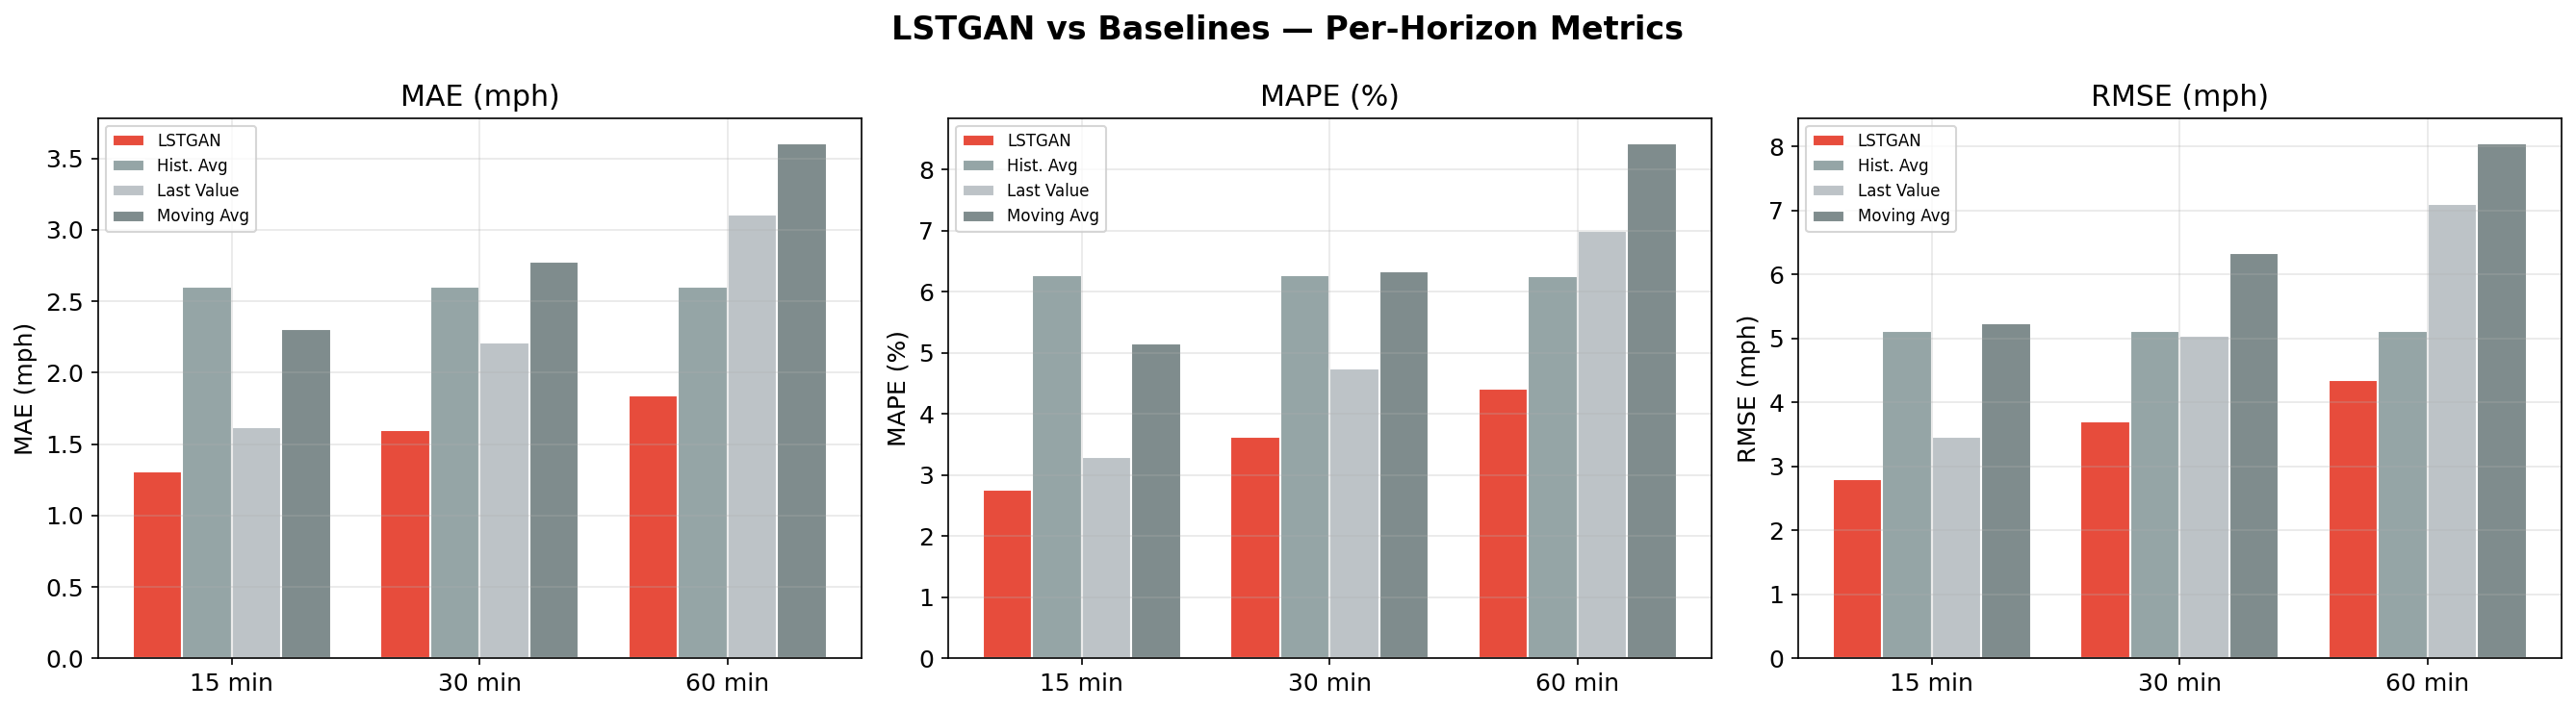

✓ Saved baseline_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LSTGAN vs Baselines — Per-Horizon Metrics', fontsize=16, fontweight='bold')

models = ['LSTGAN', 'Hist. Avg', 'Last Value', 'Moving Avg']
all_metrics = [lstgan_metrics, ha_metrics, lv_metrics, ma_metrics]
colors = ['#e74c3c', '#95a5a6', '#bdc3c7', '#7f8c8d']

for ax, metric_name, ylabel in zip(axes, ['MAE', 'MAPE', 'RMSE'], ['MAE (mph)', 'MAPE (%)', 'RMSE (mph)']):
    x = np.arange(3)
    width = 0.2
    for i, (name, metrics) in enumerate(zip(models, all_metrics)):
        vals = [metrics[h][metric_name] for h in [3, 6, 12]]
        bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i], edgecolor='white')
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(['15 min', '30 min', '60 min'])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved baseline_comparison.png')

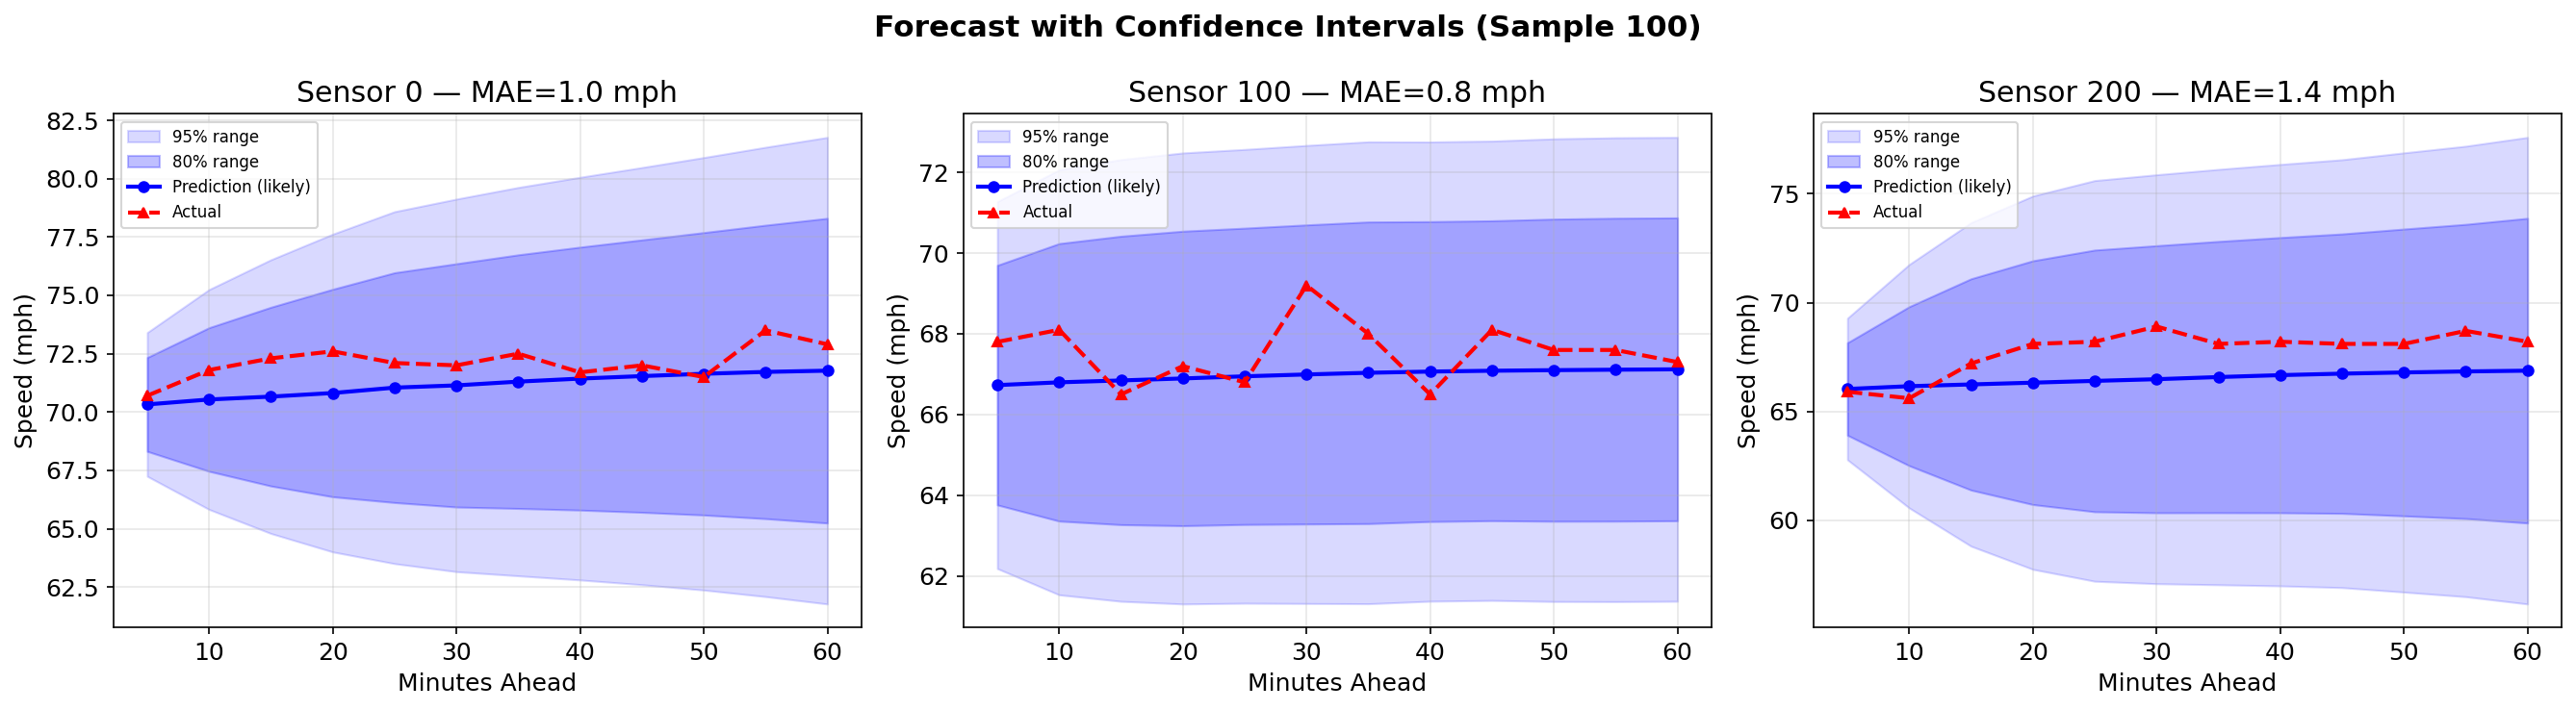

 FORECAST SUMMARY — Sensor 0
Next 60 minutes: central estimate 71.8 mph
  Lower bound (95%): 61.8 mph
  Upper bound (95%): 81.8 mph
Trend: increasing (+2.1% over forecast period)

 FORECAST SUMMARY — Sensor 100
Next 60 minutes: central estimate 67.1 mph
  Lower bound (95%): 61.4 mph
  Upper bound (95%): 72.9 mph
Trend: increasing (+0.6% over forecast period)

 FORECAST SUMMARY — Sensor 200
Next 60 minutes: central estimate 66.9 mph
  Lower bound (95%): 56.1 mph
  Upper bound (95%): 77.6 mph
Trend: increasing (+1.3% over forecast period)



In [11]:

def forecast_with_intervals(sample_idx, sensor_ids=[0, 100, 200]):
    """Generate forecast with confidence bands for selected sensors."""
    pred = test_preds[sample_idx]   # (12, 325, 1)
    actual = test_actuals[sample_idx]

    fig, axes = plt.subplots(1, len(sensor_ids), figsize=(6*len(sensor_ids), 5))
    if len(sensor_ids) == 1: axes = [axes]
    fig.suptitle(f'Forecast with Confidence Intervals (Sample {sample_idx})', fontsize=15, fontweight='bold')

    steps = np.arange(1, FORECAST_HORIZON+1) * 5

    for ax, sid in zip(axes, sensor_ids):
        p = pred[:, sid, 0]
        a = actual[:, sid, 0]
        sigma = residual_std[:, sid, 0]


        lo_95 = p - 1.96 * sigma
        hi_95 = p + 1.96 * sigma
        lo_80 = p - 1.28 * sigma
        hi_80 = p + 1.28 * sigma

        ax.fill_between(steps, lo_95, hi_95, alpha=0.15, color='blue', label='95% range')
        ax.fill_between(steps, lo_80, hi_80, alpha=0.25, color='blue', label='80% range')
        ax.plot(steps, p, 'b-o', linewidth=2, markersize=5, label='Prediction (likely)')
        ax.plot(steps, a, 'r--^', linewidth=2, markersize=5, label='Actual')

        mae = np.mean(np.abs(p - a))
        ax.set_title(f'Sensor {sid} — MAE={mae:.1f} mph')
        ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('/content/confidence_intervals.png', dpi=150, bbox_inches='tight')
    plt.show()

forecast_with_intervals(100, [0, 100, 200, 300][:3])

def generate_forecast_summary(sample_idx, sensor_id):
    p = test_preds[sample_idx, :, sensor_id, 0]
    sigma = residual_std[:, sensor_id, 0]

    central = p[-1]
    lo = p[-1] - 1.96 * sigma[-1]
    hi = p[-1] + 1.96 * sigma[-1]

    trend = 'increasing' if p[-1] > p[0] else 'decreasing' if p[-1] < p[0] else 'stable'
    change_pct = ((p[-1] - p[0]) / (p[0] + 1e-8)) * 100

    summary = (
        f" FORECAST SUMMARY — Sensor {sensor_id}\n"

        f"Next 60 minutes: central estimate {central:.1f} mph\n"
        f"  Lower bound (95%): {lo:.1f} mph\n"
        f"  Upper bound (95%): {hi:.1f} mph\n"
        f"Trend: {trend} ({change_pct:+.1f}% over forecast period)\n"
    )
    return summary

for s in [0, 100, 200]:
    print(generate_forecast_summary(100, s))

In [12]:

def detect_anomalies(preds, actuals, residual_std, threshold=2.0):
    """Flag anomalies where |actual - predicted| > threshold * sigma."""
    errors = actuals - preds  # (N, 12, 325, 1)
    z_scores = errors / (residual_std[np.newaxis, :, :, :] + 1e-8)
    is_anomaly = np.abs(z_scores) > threshold
    return is_anomaly, z_scores

anomaly_flags, z_scores = detect_anomalies(test_preds, test_actuals, residual_std)


total_points = anomaly_flags.size
n_anomalies = anomaly_flags.sum()
anomaly_rate = n_anomalies / total_points * 100


sensor_anomaly_count = anomaly_flags.sum(axis=(0, 1, 3))  # (325,)
top_anomaly_sensors = np.argsort(sensor_anomaly_count)[-10:][::-1]

print(f'Total data points:   {total_points:,}')
print(f'Anomalies detected:  {n_anomalies:,} ({anomaly_rate:.2f}%)')
print(f'\nTop 10 most anomalous sensors:')
for rank, sid in enumerate(top_anomaly_sensors, 1):
    print(f'  #{rank}: Sensor {sid} — {sensor_anomaly_count[sid]} anomalies')

Total data points:   32,748,300
Anomalies detected:  1,339,463 (4.09%)

Top 10 most anomalous sensors:
  #1: Sensor 16 — 20357 anomalies
  #2: Sensor 53 — 11363 anomalies
  #3: Sensor 20 — 10754 anomalies
  #4: Sensor 120 — 9710 anomalies
  #5: Sensor 152 — 9478 anomalies
  #6: Sensor 313 — 9342 anomalies
  #7: Sensor 13 — 8635 anomalies
  #8: Sensor 115 — 8249 anomalies
  #9: Sensor 207 — 8216 anomalies
  #10: Sensor 251 — 8165 anomalies


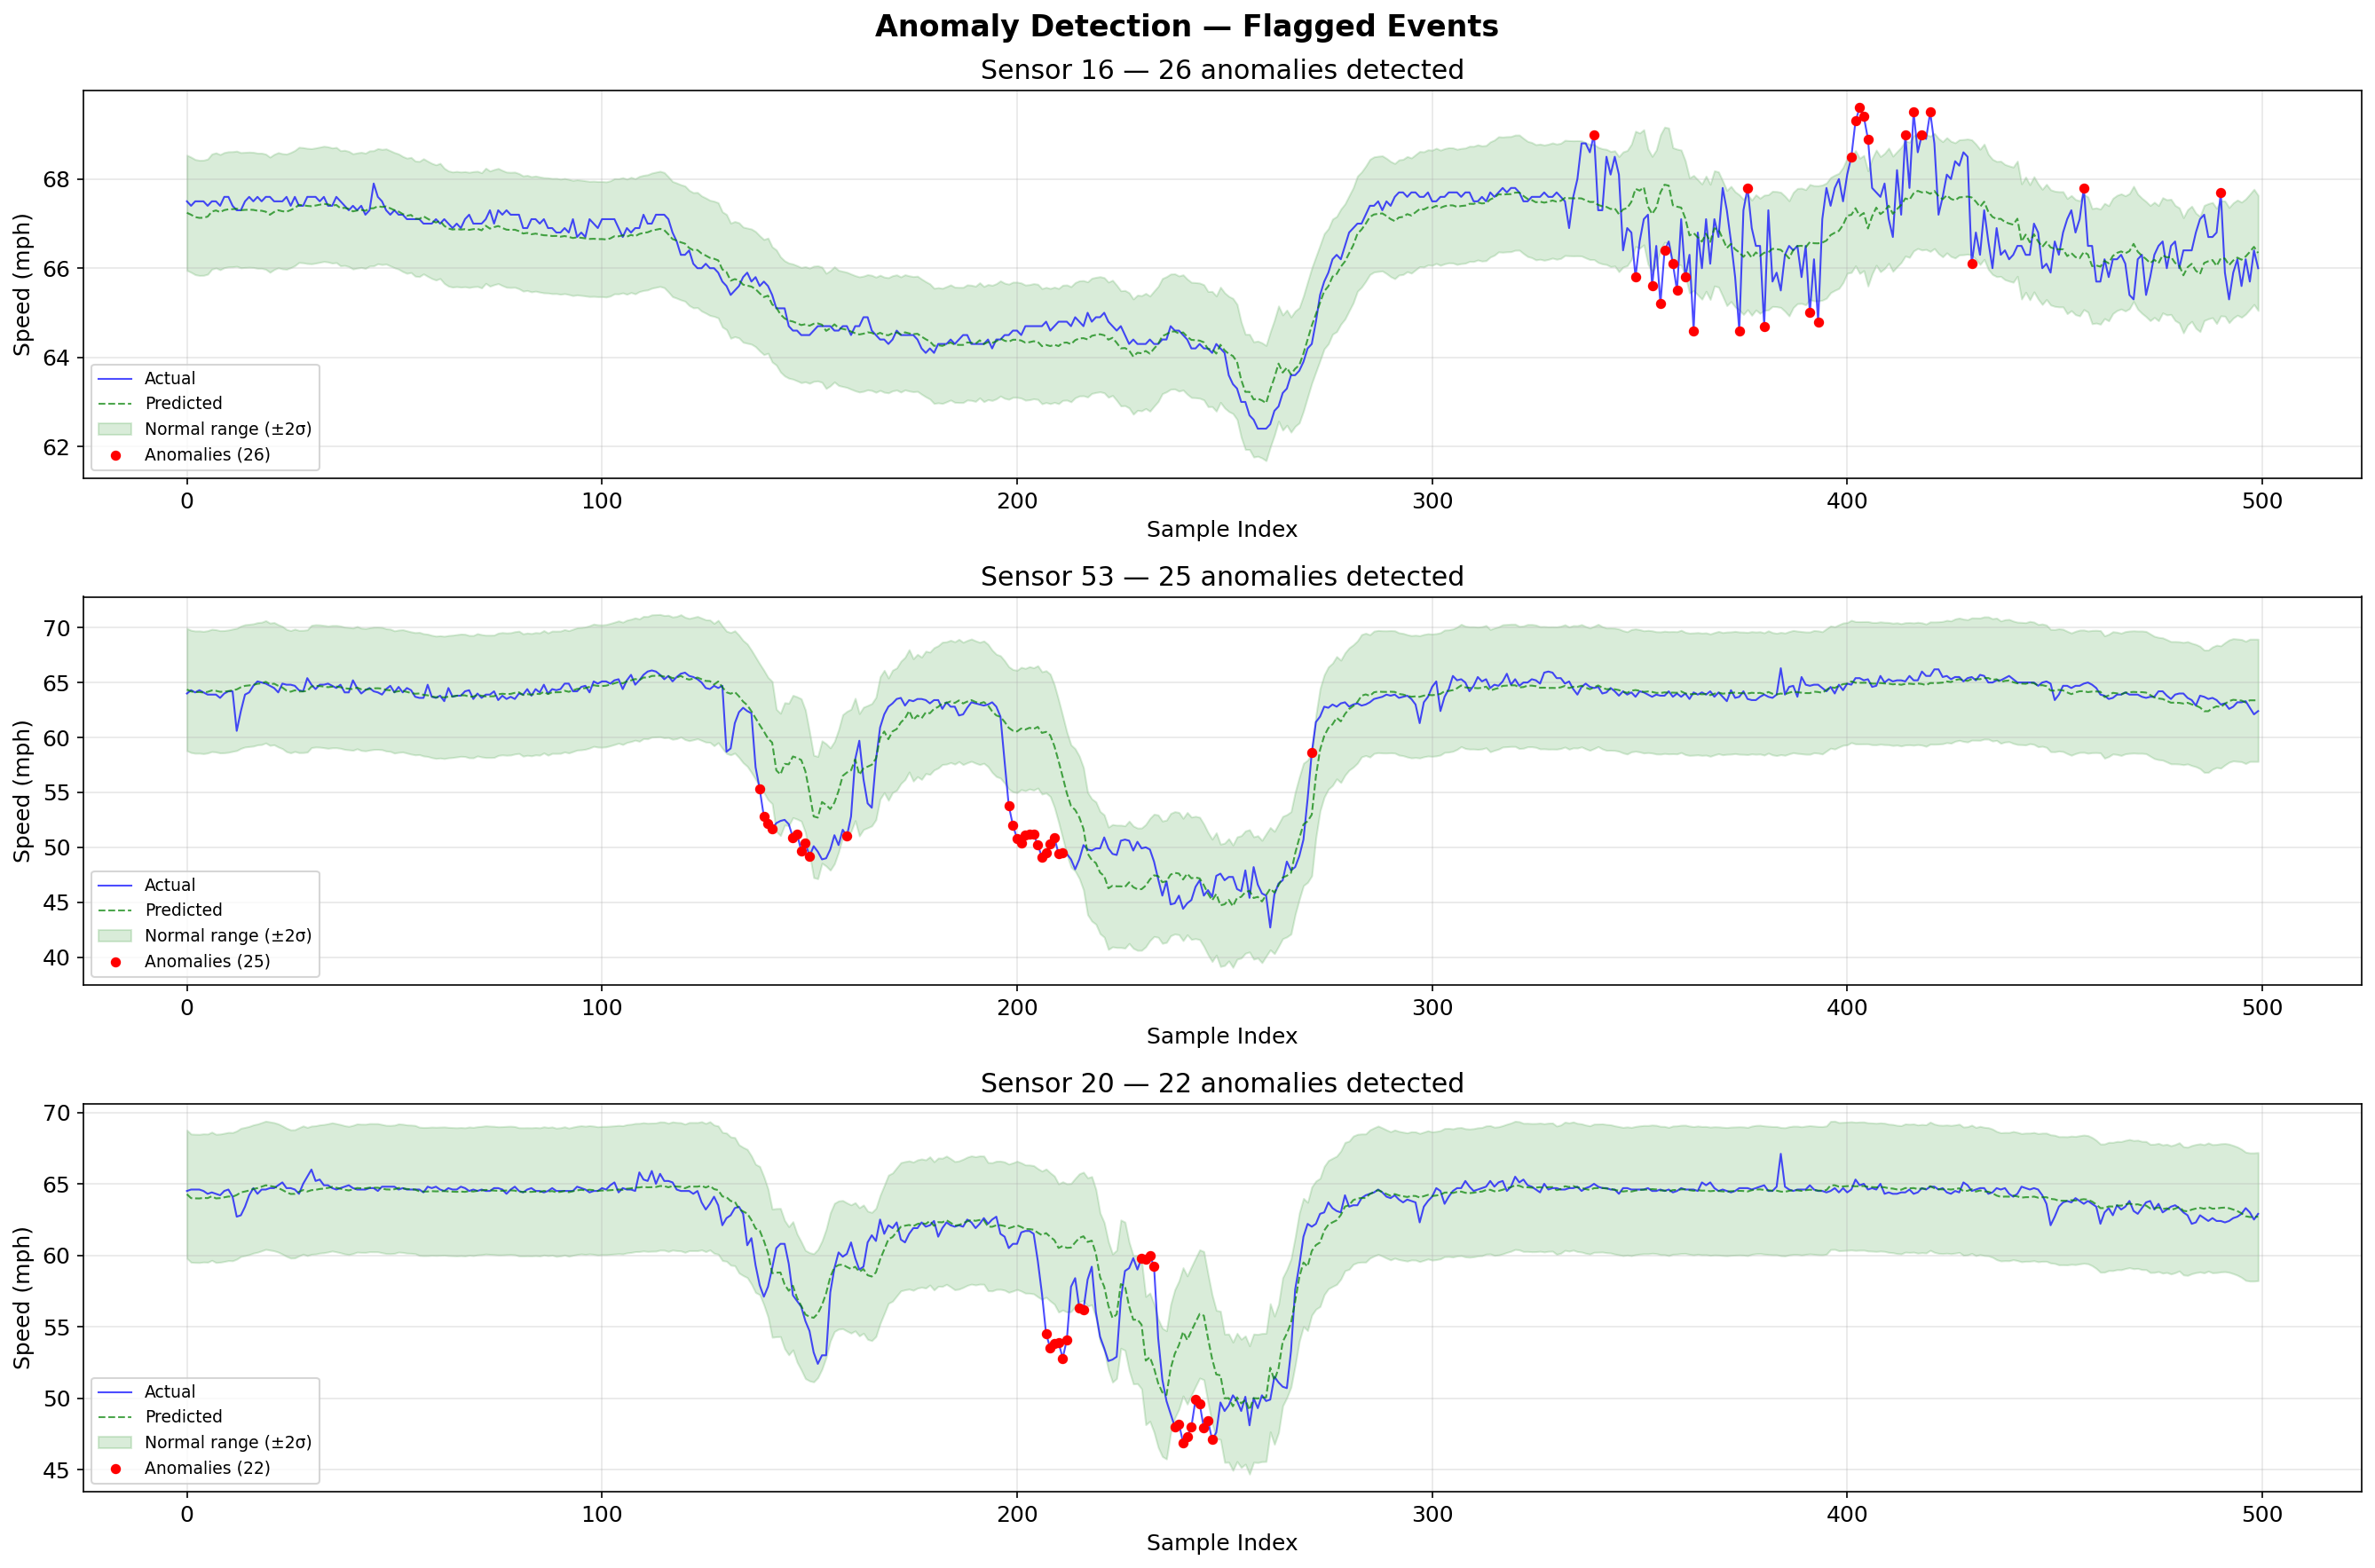

✓ Saved anomaly_detection.png


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('Anomaly Detection — Flagged Events', fontsize=16, fontweight='bold')

demo_sensors = top_anomaly_sensors[:3]
horizon_idx = 11  # 60-min horizon
show_range = min(500, len(test_preds))

for ax, sid in zip(axes, demo_sensors):
    actual = test_actuals[:show_range, horizon_idx, sid, 0]
    predicted = test_preds[:show_range, horizon_idx, sid, 0]
    sigma = residual_std[horizon_idx, sid, 0]
    flags = anomaly_flags[:show_range, horizon_idx, sid, 0]

    ax.plot(actual, 'b-', alpha=0.7, linewidth=1, label='Actual')
    ax.plot(predicted, 'g--', alpha=0.7, linewidth=1, label='Predicted')
    ax.fill_between(range(show_range), predicted - 2*sigma, predicted + 2*sigma,
                     alpha=0.15, color='green', label='Normal range (±2σ)')

    anom_idx = np.where(flags)[0]
    ax.scatter(anom_idx, actual[anom_idx], c='red', s=20, zorder=5, label=f'Anomalies ({len(anom_idx)})')

    ax.set_title(f'Sensor {sid} — {len(anom_idx)} anomalies detected')
    ax.set_xlabel('Sample Index'); ax.set_ylabel('Speed (mph)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved anomaly_detection.png')

In [14]:
def generate_anomaly_report(sample_idx, horizon_idx=11):
    """Generate a natural-language anomaly report for a given sample."""
    flags = anomaly_flags[sample_idx, horizon_idx, :, 0]  # (325,)
    anom_sensors = np.where(flags)[0]

    if len(anom_sensors) == 0:
        return f"Sample {sample_idx}: No anomalies. All 325 sensors within normal range."

    report = f"ANOMALY REPORT — Sample {sample_idx} (60-min horizon)\n"
    report += f"  {len(anom_sensors)} out of 325 sensors flagged as anomalous\n\n"

    for sid in anom_sensors[:5]:  # top 5
        actual = test_actuals[sample_idx, horizon_idx, sid, 0]
        predicted = test_preds[sample_idx, horizon_idx, sid, 0]
        z = z_scores[sample_idx, horizon_idx, sid, 0]
        direction = 'above' if z > 0 else 'below'
        report += (f"  Sensor {sid}: actual={actual:.1f} mph, expected={predicted:.1f} mph "
                   f"({direction} normal, z={z:.1f})\n")

    if len(anom_sensors) > 5:
        report += f"  ... and {len(anom_sensors)-5} more sensors\n"

    report += f"\n  Suggested action: Investigate sensors {list(anom_sensors[:3])} for possible incidents.\n"
    return report


sample_anomaly_counts = anomaly_flags[:, 11, :, 0].sum(axis=1)
worst_sample = np.argmax(sample_anomaly_counts)
print(generate_anomaly_report(worst_sample))

ANOMALY REPORT — Sample 3801 (60-min horizon)
  218 out of 325 sensors flagged as anomalous

  Sensor 0: actual=-0.0 mph, expected=70.8 mph (below normal, z=-13.9)
  Sensor 3: actual=-0.0 mph, expected=67.3 mph (below normal, z=-16.0)
  Sensor 5: actual=-0.0 mph, expected=66.3 mph (below normal, z=-10.4)
  Sensor 6: actual=-0.0 mph, expected=66.1 mph (below normal, z=-9.3)
  Sensor 7: actual=-0.0 mph, expected=67.3 mph (below normal, z=-15.4)
  ... and 213 more sensors

  Suggested action: Investigate sensors [np.int64(0), np.int64(3), np.int64(5)] for possible incidents.



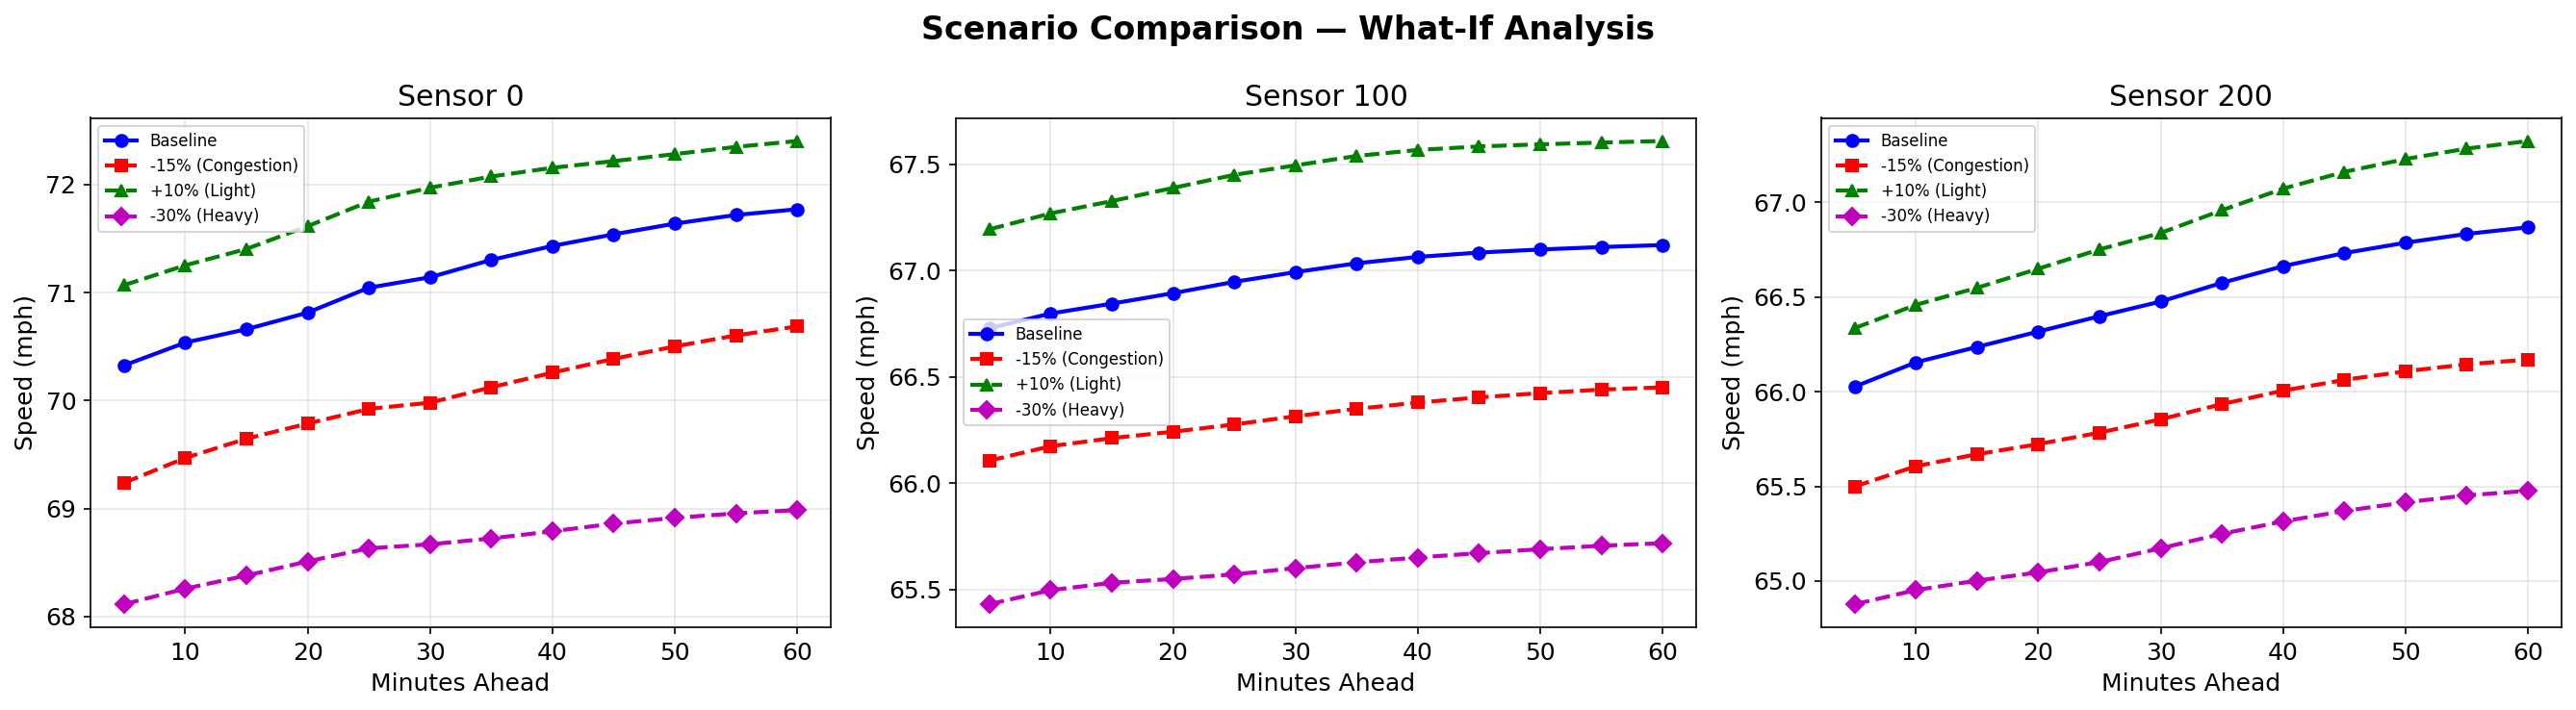


SCENARIO IMPACT SUMMARY — Sensor 100
  Baseline (60-min):    67.1 mph
  -15% congestion:      66.5 mph (Δ = -0.7 mph)
  +10% light traffic:   67.6 mph (Δ = +0.5 mph)
  -30% heavy:           65.7 mph (Δ = -1.4 mph)


In [15]:

def run_scenario(sample_idx, speed_multiplier=1.0, label='Baseline'):
    """Run a what-if scenario by scaling input speeds."""
    sample = test_ds[sample_idx]
    Xw, Xd, Xh, ti, Y = [s.unsqueeze(0).to(DEVICE) for s in sample]

    Xw_s = Xw.clone(); Xw_s[:,:,:,0] *= speed_multiplier
    Xd_s = Xd.clone(); Xd_s[:,:,:,0] *= speed_multiplier
    Xh_s = Xh * speed_multiplier

    model.eval()
    with torch.no_grad():
        pred = model(Xw_s, Xd_s, Xh_s, ti, edge_index, edge_weight)

    return (pred.cpu().numpy() * train_std + train_mean)[0, :, :, 0]  # (12, 325)

sample_idx = 100

# Run scenarios
baseline   = run_scenario(sample_idx, 1.0,  'Baseline')
congestion = run_scenario(sample_idx, 0.85, '-15% Speed (Congestion)')  # slower = more traffic
light      = run_scenario(sample_idx, 1.10, '+10% Speed (Light Traffic)')
heavy      = run_scenario(sample_idx, 0.70, '-30% Speed (Heavy Congestion)')

sensors_to_show = [0, 100, 200]
fig, axes = plt.subplots(1, len(sensors_to_show), figsize=(6*len(sensors_to_show), 5))
fig.suptitle('Scenario Comparison — What-If Analysis', fontsize=16, fontweight='bold')

steps = np.arange(1, FORECAST_HORIZON+1) * 5
for ax, sid in zip(axes, sensors_to_show):
    ax.plot(steps, baseline[:, sid],   'b-o',  linewidth=2, label='Baseline')
    ax.plot(steps, congestion[:, sid], 'r--s',  linewidth=2, label='-15% (Congestion)')
    ax.plot(steps, light[:, sid],      'g--^',  linewidth=2, label='+10% (Light)')
    ax.plot(steps, heavy[:, sid],      'm--D',  linewidth=2, label='-30% (Heavy)')
    ax.set_title(f'Sensor {sid}')
    ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

sid = 100
base_60 = baseline[-1, sid]
cong_60 = congestion[-1, sid]
print(f'\nSCENARIO IMPACT SUMMARY — Sensor {sid}')

print(f'  Baseline (60-min):    {base_60:.1f} mph')
print(f'  -15% congestion:      {cong_60:.1f} mph (Δ = {cong_60-base_60:+.1f} mph)')
print(f'  +10% light traffic:   {light[-1,sid]:.1f} mph (Δ = {light[-1,sid]-base_60:+.1f} mph)')
print(f'  -30% heavy:           {heavy[-1,sid]:.1f} mph (Δ = {heavy[-1,sid]-base_60:+.1f} mph)')

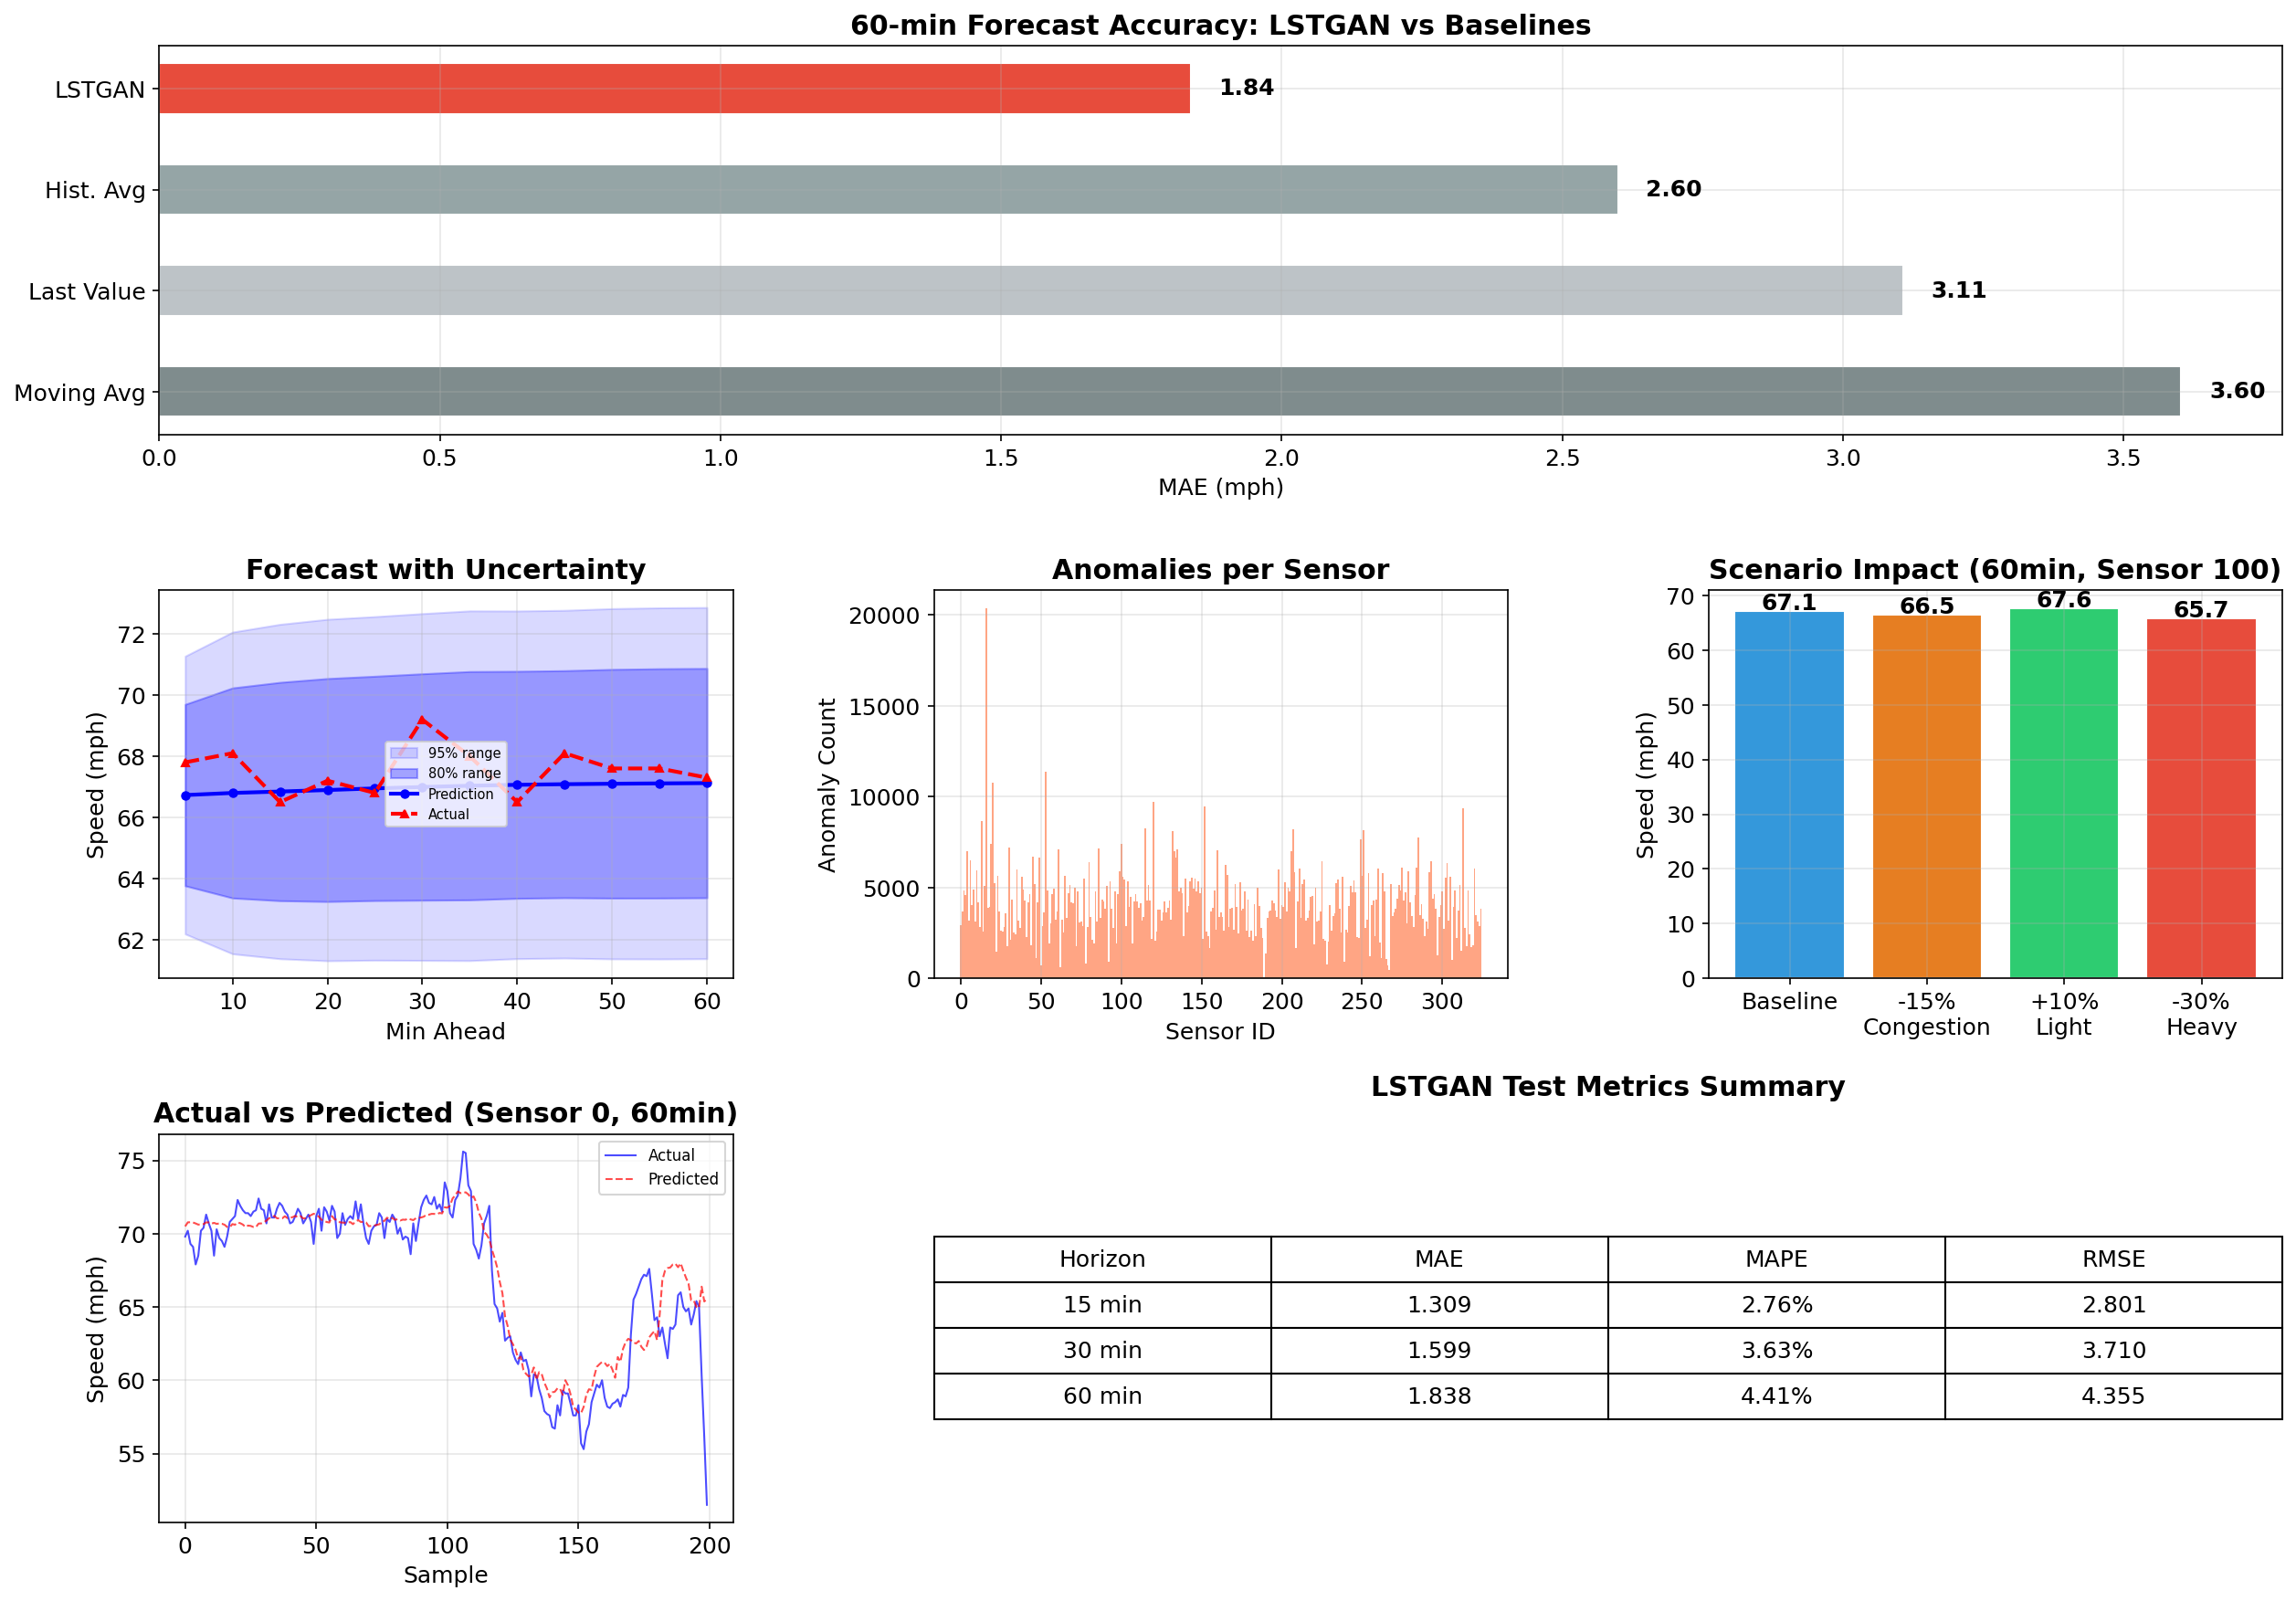

✓ Saved executive_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
models_list = ['LSTGAN', 'Hist. Avg', 'Last Value', 'Moving Avg']
mae_60 = [lstgan_metrics[12]['MAE'], ha_metrics[12]['MAE'], lv_metrics[12]['MAE'], ma_metrics[12]['MAE']]
colors_bar = ['#e74c3c', '#95a5a6', '#bdc3c7', '#7f8c8d']
bars = ax1.barh(models_list, mae_60, color=colors_bar, edgecolor='white', height=0.5)
for bar, v in zip(bars, mae_60):
    ax1.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontweight='bold')
ax1.set_xlabel('MAE (mph)'); ax1.set_title('60-min Forecast Accuracy: LSTGAN vs Baselines', fontweight='bold')
ax1.invert_yaxis()

ax2 = fig.add_subplot(gs[1, 0])
sid = 100; sample = 100
p = test_preds[sample, :, sid, 0]; sigma = residual_std[:, sid, 0]
a = test_actuals[sample, :, sid, 0]
steps = np.arange(1, 13)*5
ax2.fill_between(steps, p-1.96*sigma, p+1.96*sigma, alpha=0.15, color='blue', label='95% range')
ax2.fill_between(steps, p-1.28*sigma, p+1.28*sigma, alpha=0.3, color='blue', label='80% range')
ax2.plot(steps, p, 'b-o', linewidth=2, markersize=4, label='Prediction')
ax2.plot(steps, a, 'r--^', linewidth=2, markersize=4, label='Actual')
ax2.set_title('Forecast with Uncertainty', fontweight='bold')
ax2.set_xlabel('Min Ahead'); ax2.set_ylabel('Speed (mph)'); ax2.legend(fontsize=7)

ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(range(NUM_SENSORS), sensor_anomaly_count, color='coral', width=1.0, alpha=0.7)
ax3.set_xlabel('Sensor ID'); ax3.set_ylabel('Anomaly Count')
ax3.set_title('Anomalies per Sensor', fontweight='bold')


ax4 = fig.add_subplot(gs[1, 2])
scenarios = ['Baseline', '-15%\nCongestion', '+10%\nLight', '-30%\nHeavy']
vals = [baseline[-1,100], congestion[-1,100], light[-1,100], heavy[-1,100]]
colors_sc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
ax4.bar(scenarios, vals, color=colors_sc, edgecolor='white')
for i, v in enumerate(vals): ax4.text(i, v+0.3, f'{v:.1f}', ha='center', fontweight='bold')
ax4.set_ylabel('Speed (mph)'); ax4.set_title('Scenario Impact (60min, Sensor 100)', fontweight='bold')


ax5 = fig.add_subplot(gs[2, 0])
show = min(200, len(test_preds))
ax5.plot(test_actuals[:show, 11, 0, 0], 'b-', alpha=0.7, linewidth=1, label='Actual')
ax5.plot(test_preds[:show, 11, 0, 0], 'r--', alpha=0.7, linewidth=1, label='Predicted')
ax5.set_title('Actual vs Predicted (Sensor 0, 60min)', fontweight='bold')
ax5.legend(fontsize=8); ax5.set_xlabel('Sample'); ax5.set_ylabel('Speed (mph)')

ax6 = fig.add_subplot(gs[2, 1:])
table_data = []
for h in [3, 6, 12]:
    m = lstgan_metrics[h]
    table_data.append([f'{h*5} min', f'{m["MAE"]:.3f}', f'{m["MAPE"]:.2f}%', f'{m["RMSE"]:.3f}'])
table = ax6.table(cellText=table_data, colLabels=['Horizon', 'MAE', 'MAPE', 'RMSE'],
                   loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(12); table.scale(1, 2)
ax6.axis('off'); ax6.set_title('LSTGAN Test Metrics Summary', fontweight='bold', pad=20)

plt.savefig('/content/executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved executive_dashboard.png')

In [17]:

print('  LSTGAN — AI PREDICTIVE FORECASTING — EXECUTIVE SUMMARY')

print()
print('MODEL: LSTGAN (Long-Term Spatio-Temporal Graph Attention Network)')
print(f'   Parameters: {n_params:,} | Trained on: PeMS-Bay (325 sensors)')
print(f'   Resolution: 5-minute intervals | Horizons: 15/30/60 min')
print()
print('ACCURACY (60-min horizon — hardest prediction):')
m = lstgan_metrics[12]
print(f'   MAE  = {m["MAE"]:.3f} mph  (avg error per prediction)')
print(f'   MAPE = {m["MAPE"]:.2f}%   (percentage error)')
print(f'   RMSE = {m["RMSE"]:.3f} mph  (penalizes large errors)')
print()
print('IMPROVEMENT OVER BASELINES (60-min):')
for name, metrics in [('Historical Average', ha_metrics), ('Last Value', lv_metrics), ('Moving Average', ma_metrics)]:
    improv = (1 - lstgan_metrics[12]['MAE'] / metrics[12]['MAE']) * 100
    print(f'   vs {name:20s}: {improv:+.1f}% better MAE')
print()
print(f'ANOMALY DETECTION: {n_anomalies:,} events flagged ({anomaly_rate:.2f}% of all data points)')
print(f'   Most affected sensors: {list(top_anomaly_sensors[:5])}')
print()
print('SCENARIO ANALYSIS: Model responds to input changes')
print(f'   -15% speed → {congestion[-1,100]:.1f} mph at Sensor 100 (vs {baseline[-1,100]:.1f} baseline)')
print(f'   -30% speed → {heavy[-1,100]:.1f} mph at Sensor 100')
print()
print('KEY STRENGTHS:')
print('   • Graph neural networks capture spatial road-network relationships')
print('   • Multi-scale temporal encoding (weekly + daily + hourly patterns)')
print('   • Lightweight (109K params) — runs on free-tier GPU')
print('   • Transparent: baselines, uncertainty ranges, explainable outputs')

  LSTGAN — AI PREDICTIVE FORECASTING — EXECUTIVE SUMMARY

MODEL: LSTGAN (Long-Term Spatio-Temporal Graph Attention Network)
   Parameters: 109,428 | Trained on: PeMS-Bay (325 sensors)
   Resolution: 5-minute intervals | Horizons: 15/30/60 min

ACCURACY (60-min horizon — hardest prediction):
   MAE  = 1.838 mph  (avg error per prediction)
   MAPE = 4.41%   (percentage error)
   RMSE = 4.355 mph  (penalizes large errors)

IMPROVEMENT OVER BASELINES (60-min):
   vs Historical Average  : +29.3% better MAE
   vs Last Value          : +40.9% better MAE
   vs Moving Average      : +49.0% better MAE

ANOMALY DETECTION: 1,339,463 events flagged (4.09% of all data points)
   Most affected sensors: [np.int64(16), np.int64(53), np.int64(20), np.int64(120), np.int64(152)]

SCENARIO ANALYSIS: Model responds to input changes
   -15% speed → 66.5 mph at Sensor 100 (vs 67.1 baseline)
   -30% speed → 65.7 mph at Sensor 100

KEY STRENGTHS:
   • Graph neural networks capture spatial road-network relations